# 🏠 Aged Care Quality Prediction: ML for Elderly Care Standards

**Author:** Dean | Lead Data & AI Engineer

**Government:** Aged Care Quality & Safety Commission, Dept of Health, Royal Commission response

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2000, 13)


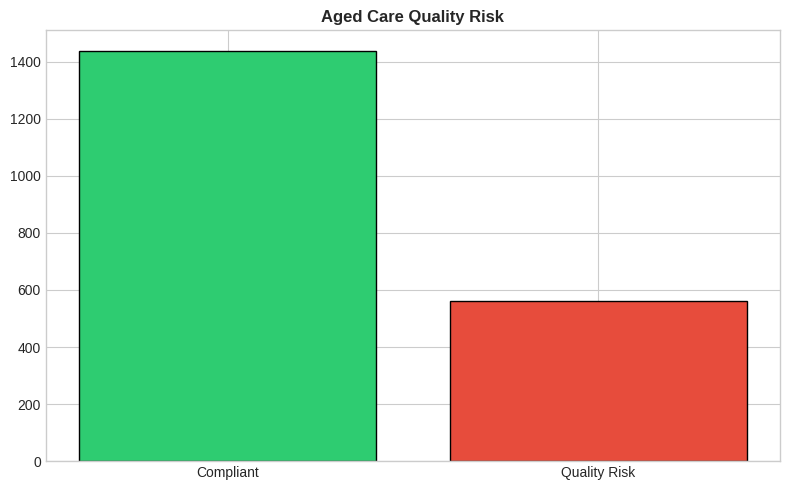

AU: Royal Commission found systemic failures. New Aged Care Act 2024 reforms quality standards.


In [1]:
import warnings,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=12,n_informative=8,n_classes=2,weights=[0.72,0.28],random_state=69)
names=['staff_to_resident_ratio','rn_hours_per_day','complaints_per_100','falls_rate','pressure_injury_rate','medication_errors','unplanned_hospital_transfers','restraint_usage','resident_satisfaction','staff_turnover_pct','accreditation_score','funding_per_resident']
df=pd.DataFrame(X_arr,columns=names);df['quality_risk']=y;tc='quality_risk'
print(f"Generated: {df.shape}");labels=['Compliant','Quality Risk'];colors=['#2ecc71','#e74c3c']
fig,ax=plt.subplots(figsize=(8,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(2),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(2));ax.set_xticklabels(labels)
ax.set_title('Aged Care Quality Risk',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: Royal Commission found systemic failures. New Aged Care Act 2024 reforms quality standards.")

LogReg: Acc=0.8840 F1=0.7869 AUC=0.9327
RF: Acc=0.9340 F1=0.8763 AUC=0.9750
XGB: Acc=0.9540 F1=0.9148 AUC=0.9831
LGBM: Acc=0.9560 F1=0.9197 AUC=0.9848
Best: LGBM


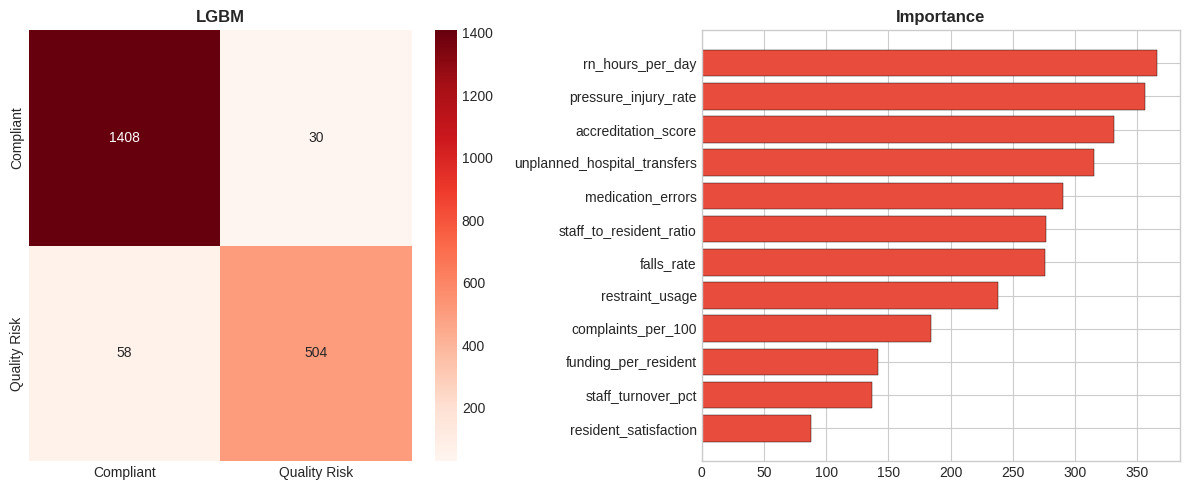

              precision    recall  f1-score   support

   Compliant       0.96      0.98      0.97      1438
Quality Risk       0.94      0.90      0.92       562

    accuracy                           0.96      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.96      0.96      0.96      2000

DEPLOYMENT: LGBM AUC=0.9848 | Aged Care Commission risk-based regulation


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp));fu.append(roc_auc_score(y2[vi],yb))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")
best=max(results,key=lambda k:results[k]['auc']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=labels,yticklabels=labels,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#e74c3c',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=labels))
br=results[best];print(f"DEPLOYMENT: {best} AUC={br['auc']:.4f} | Aged Care Commission risk-based regulation")